In [1]:
from sklearn.datasets import load_iris
dataset = load_iris()

In [2]:
X = dataset.data
Y = dataset.target

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)

In [5]:
pip install -q lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import lightgbm as lgb

In [7]:
train_data = lgb.Dataset(X_train, label=Y_train)
test_data = lgb.Dataset(X_test, label=Y_test, reference=train_data)

In [8]:
params = {
    'objective': 'regression',
    'metric': 'mse',
    'verbose': -1
}

In [9]:
model = lgb.train(params, train_data, num_boost_round=20, valid_sets=[test_data])

In [10]:
Y_Pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(Y_test, Y_Pred)
mse = mean_squared_error(Y_test, Y_Pred)
print(r2)
print(mse)

0.9673575296220083
0.022632112795407607


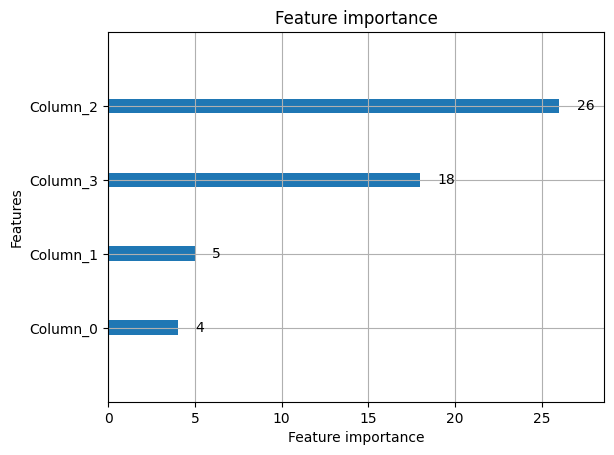

In [12]:
import matplotlib.pyplot as plt
lgb.plot_importance(model)
plt.show()